# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use general linear models in analysis when an outcome is binary 0/1 to make predictions. We do this with logistic regression. If an outcome is categorical, we can use multinomial logistic regression to predict probabilities. These general linear models have an advantage over linear models because linear models only return a numeric value between negative infinity and infinity. Essentially, with linear models, we can't restrict the bounds to values we want (ex: values between 0 and 1). This is problematic because we can't interpret outcomes below 0 and above 1 as probabilities, especially in clinical contexts. However, we can do this with general linear models.
2. Binary cross entropy and categorical cross entropy are both effective loss functions because cross entropy measures the distance between two probability distributions, the predicted and actual. This is significant because other measures of accuracy such as Mean Squared Error only measures the distance between two numbers. Measuring probability distributions are better as cross entropy uses a logarithmic scale, which is better at "punishing" misclassifications.
3. Despite having an S-shaped curve, logistic regression is considered a linear model and is classified as a generalized linear model. This means that the output depends on the sum of its inputs; in other words, the output is a linear combination of parameters.
4. Logistic regression can also be used for classification. This is because it's considered a general linear model and is useful when the outcome we're predicting is binary. Classification predicts discrete outputs, which the binary values of 0 and 1 are considered.
5. The coefficient in a logistic regression doesn't represent the change in the predicted value for a 1 unit change. This is because logistic functions have an S-shaped distribution. The S-shape prevents a fixed slope since the slope depends on where you are on the curve, and a single coefficient doesn't represent this change in the predicted value.
6. This statement is false. Logistic regression models can only interpret straight-line relationships, so feature engineering can address that limitation; therefore, feature engineering is necessary for logistic regression. Logistic regression is a linear model, so it can't see non-linear relationships. While the logistic regression model itself can't see curves or other complex shapes, features can be manually engineered to account for these complex relationships. This illustrates the importance of feature engineering.
7. This statement is false. You shouldn't always use logistic regression over Ordinary Least Squares because they are utilized for different purposes. We should use OLS when the outcome is continuous and the relationship can go to infinity. We should use logistic regression when the predicted outcomes are binary or categorical and need to keep predictions between 0 and 1. These two modeling tools shouldn't be used interchangeably as we'd sacrifice interpretability and complexity in our results. 

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [172]:
#1: reading in the data
import numpy as np
import pandas as pd

df = pd.read_csv('./data/data.csv', sep=';', encoding='utf-8-sig')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [173]:
#1: handling missing values
initial = len(df)
df = df.dropna()
dropped_count = initial - len(df)
print(dropped_count)

0


Question 1: I handled any missing values by using the .dropna() operation on my initial data set. However, after subtracting the length of the data after dropping missing values from the length of the data before, I see that the answer is 0. This means that there wasn't actually any missing values in the data to begin with.

In [174]:
#1: filtering for variables we'll use
df = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']]

In [175]:
#1: creating a binary target
df['Dropout'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [176]:
#2
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Dropout']

reg = LogisticRegression(penalty=None)
reg.fit(X, y)

pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


Question 2: Debtor predicts the highest dropout probability with a positive coefficient of 0.527. Age at enrollment also predicts a higher dropout probability with a positive coefficient of 0.049. Tuition fees up to date predicts the lowest dropout probability with a coefficient of -2.606. Scholarship holder is also a predictor of a lower dropout probability. In translation, these two variables reduce the probability of dropping out. Specifically, being up to date on tuition seems to significantly reduce dropout risk since it's negative and has the largest absolute value.

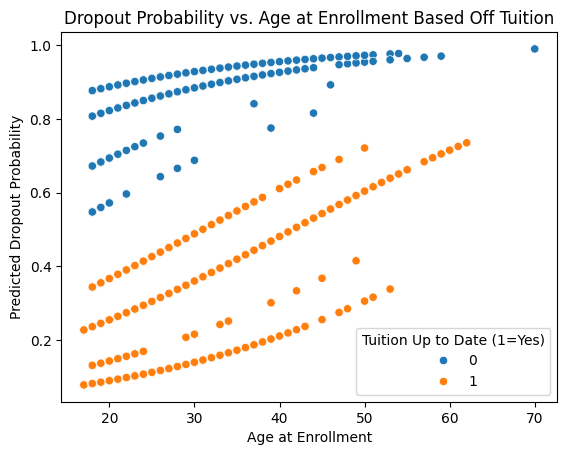

In [177]:
#3: scatter plot of predicted probabilities
import matplotlib.pyplot as plt
import seaborn as sns

y_reg = reg.predict_proba(X)
df['pred_prob'] = [ row[1] for row in y_reg]
sns.scatterplot(df, x = 'Age at enrollment', y = 'pred_prob', hue = 'Tuition fees up to date')
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.title('Dropout Probability vs. Age at Enrollment Based Off Tuition')
plt.legend(title='Tuition Up to Date (1=Yes)')
plt.show()

Question 3: Students who are in the middle-to-late stages of age and keep their tuition up to date seem to have the most reduced dropout risk. 

In [178]:
#3: calculating the average
average_up_to_date = df[df['Tuition fees up to date'] == 1]['pred_prob'].mean()
average_not = df[df['Tuition fees up to date'] == 0]['pred_prob'].mean()

print(f"Average based on up to date tuition: {average_up_to_date}")
print(f"Average based on overdue tuition: {average_not}")
print(f"Difference: {abs(average_up_to_date - average_not)}")

Average based on up to date tuition: 0.24743273200260263
Average based on overdue tuition: 0.8655333468714455
Difference: 0.6181006148688428


Question 3: On average, the change is 0.618 in the predicted probability of a student dropping out when tuition is up to date.

In [179]:
#4
y_class = pd.Series(reg.predict(X))

tab = pd.crosstab(y_class, df['Dropout'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Dropout     0    1
row_0             
0        2841  891
1         162  530

Accuracy: 0.7619801084990958


Question 4: The overall accuracy of my model is about 76% percent.

In [180]:
#5: predicted probabilities with a linear model
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg = reg.fit(X, y)
y_hat = reg.predict(X)

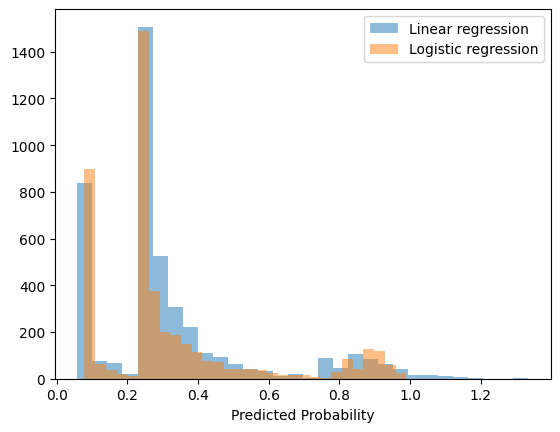

In [181]:
#5: histogram
plt.hist(x=y_hat, bins=30, alpha=0.5, label = 'Linear regression')
plt.hist(x=y_reg[:, 1], bins=30, alpha=0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show() 

Question 5: The linear and logistic regression models performed differently, and one was more problematic than the other. The linear regression model was problematic because the probabilities weren't constrained within the (0, 1) interval. We still see some predicted probabilities going beyond 1.0 that were calculated by the linear regression model. These are invalid predictions since we're looking for values between binary outcomes (0 and 1). Meanwhile, we can see that all of the predicted probabilities are valid for the logistic regression model since they're between 0 and 1.

Question 6: 

Based on my work above, students who have overdue tuition payments are the most at-risk of dropping out, especially as they get older. This is illustrated by the variable coefficient being -2.606. Translating this number into words, having up to date tuition fees is a strong predictor that a student won't drop out. Additionally, the absolute value of the coefficient was the largest value out of all the coefficients, so tuition is the strongest predictor of dropping out. Therefore, students with overdue tuition fees are most likely to drop out. The calculated average difference for a student dropping out based off tuition also supports this argument as it had a significantly large difference in probability of 0.618.   

One intervention that may help at-risk students from dropping out include advising (human or digital) that the student regularly checks in with to make sure their payments are up to date. Another intervention is improved loan programs and financial aid assistance that ensure the financial safety of students.

In [182]:
#7
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

mnl = LogisticRegression(penalty=None).fit(X_multi, y_multi)

# hard classification
y_hard_class = mnl.predict(X_multi)

# confusion matrix
pd.crosstab(y_multi, y_hard_class)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


col_0,Dropout,Graduate
Target,,
Dropout,1054,367
Enrolled,280,514
Graduate,146,2063


In [183]:
#7: predicting probabilities
pd.DataFrame(mnl.predict_proba(X_multi))

,0,1,2
0,0.680560,0.210486,0.108954
1,0.706615,0.145494,0.147892
2,0.954343,0.040341,0.005316
3,0.117346,0.176786,0.705867
4,0.183691,0.212551,0.603758
...,...,...,...
4419,0.183691,0.212551,0.603758
4420,0.790188,0.149440,0.060372
4421,0.071581,0.140405,0.788013
4422,0.183691,0.212551,0.603758


Question 7: 

Based off the confusion matrix I made, I can see that the hard classification completely ignored one of the columns, the Enrolled class. The model failed to categorize enrolled students, either grouping them into graduates or dropouts, even if they are currently enrolled. We can see that the model made false classifications, and the hard classification ultimately didn't predict every class.

On the other hand, the predicted probabilities did predict every class. Looking at the table I created, I see three columns: 0, 1, and 2. Though they're not explicitly labeled, those integers refer to all of the classes: Dropout, Enrolled, and Graduate.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [187]:
#1: reading in the data
import numpy as np
import pandas as pd

df1 = pd.read_csv('./data/cirrhosis.csv', encoding='latin1')
df1.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [189]:
#1: handling missing values
COLS = ['Status', 'Drug', 'Bilirubin', 'Edema', 'Stage']
df1 = df1[COLS]
df1.isna().sum()

Status         0
Drug         106
Bilirubin      0
Edema          0
Stage          6
dtype: int64

In [192]:
#1: dropping miss values
df1 = df1.dropna(subset='Drug')

Question 1: I handled missing values by using the .dropna() operation on the Drug portion of the data set. After seeing that Drug had 106 missing values, I performed the operation.

In [194]:
#2: converting strings into floats ->
X1 = pd.get_dummies(df1[['Edema', 'Drug', 'Bilirubin']], drop_first = True)
X1.head()

,Bilirubin,Edema_S,Edema_Y,Drug_Placebo
0,14.5,False,True,False
1,1.1,False,False,False
2,1.4,True,False,False
3,1.8,True,False,False
4,3.4,False,False,True


In [196]:
#2: logistic regression
df1['Dead'] = (df1['Status'] == 'D').astype(int)
y1 = df1['Dead']

reg = LogisticRegression(penalty=None)
reg.fit(X1, y1)

pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Bilirubin,0.350381
1,Edema_S,0.578551
2,Edema_Y,2.859322
3,Drug_Placebo,-0.252657


Question 2: 

Since the coefficient of Drug_Placebo is negative, this means that a patient given the placebo has a lower chance of death than a patient who was given the drug. This highlights how the drug doesn't improve survival probability, it actually decreases it.

A higher bilirubin predicts an increased probability of death, as illustrated by the positive coefficient of 0.350. 

The coefficient for Edema_S conveys how those with edema resolvable with diuretics has an increased probability of death. The coefficient for Edema_Y shows how those with edema that's not resolvable with diuretics has a significantly high likelihood of death. This shows that diuretics may decrease death though edema is still life-threatening.

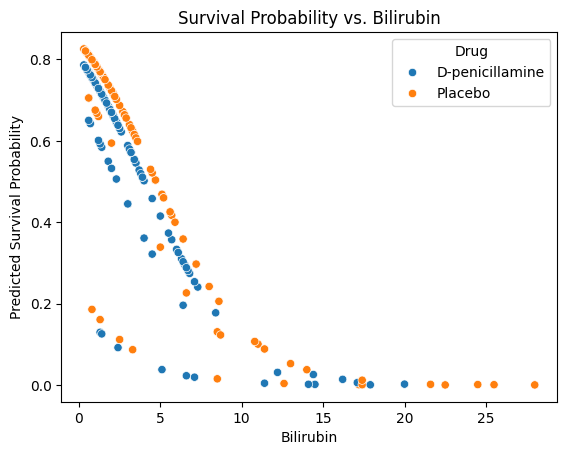

In [197]:
#3: scatterplot of survival probabilities
y1_reg = reg.predict_proba(X1)

df1['survival_prob'] = [1- row[1] for row in y1_reg]

sns.scatterplot(df1, x = 'Bilirubin', y = 'survival_prob', hue = 'Drug')
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.title('Survival Probability vs. Bilirubin')
plt.legend(title='Drug')
plt.show()

Question 3: There are no values of Bilirubin where the drug increases patient survival rate. This is illustrated by the graph where the Placebo dots are slightly higher than the Drug dots for every value of Bilirubin. It's graphically shown that the drug doesn't seem to increase the survival rate at all as the drug's negative effect on survival remains the same on all Bilirubin levels.

In [198]:
#3: calculating the average
X1['pred_prob'] = reg.predict_proba(X1.drop(columns=['pred_prob'], errors='ignore'))[:,1]

average_placebo = X1[X1['Drug_Placebo'] == 1]['pred_prob'].mean()
average_drug = X1[X1['Drug_Placebo'] == 0]['pred_prob'].mean()

print(f"Average based on patients who took the drug: {average_drug}")
print(f"Average based on patients with placebo: {average_placebo}")
print(f"Difference: {abs(average_drug - average_placebo)}")

Average based on patients who took the drug: 0.41138352982671667
Average based on patients with placebo: 0.3896066931459538
Difference: 0.021776836680762857


Question 3: The computed numbers represent the averages for the probability of death. However, the value difference in averages for both the probability of death and survival are the same. On average, the difference in the probability of survival in patients who took the drug versus patients who took the placebo was 0.022.

In [199]:
#4
cols_to_drop = ['pred_prob', 'survival_prob']   # need to drop some columns first

y1_class = pd.Series(reg.predict(X1.drop(columns=cols_to_drop, errors='ignore')))

tab = pd.crosstab(y1_class, df1['Dead'])
acc = np.trace(tab)/len(y1_class)

print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Dead     0   1
row_0         
0      173  68
1       14  57

Accuracy: 0.7371794871794872


Question 4: The overall accuracy of my model is about 74%.

In [200]:
#5: predicted probabilities with a linear model
X1_clean = X1.drop(columns=cols_to_drop, errors='ignore')
reg = LinearRegression()
reg = reg.fit(X1_clean, y1)
y1_hat = reg.predict(X1_clean)

# converting them into survival probabilities
logit_survival = 1 - y1_reg[:, 1]
linear_survival = 1 - y1_hat

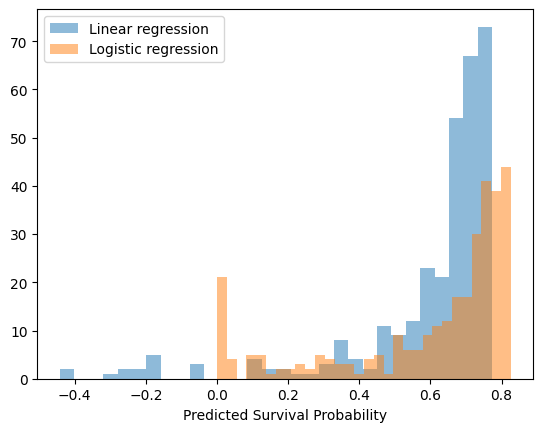

In [201]:
#5: histogram
plt.hist(x=linear_survival, bins=30, alpha=0.5, label = 'Linear regression')
plt.hist(x=logit_survival, bins=30, alpha=0.5, label='Logistic regression')
plt.xlabel('Predicted Survival Probability')
plt.legend()
plt.show() 

Question 5: Similar to the histogram I got for the last problem, I see that the logistic regression model performed better than the linear regression model. I came to this conclusion because probability values aren't constrained in the (0, 1) interval for the linear regression model. This model predicted negative values that are less than 0. These predictions are invalid since probabilities must be in between binary values of 0 and 1. On the other hand, we can see that the logistic regression model only predicted values that are between 0 and 1, making these predictions more valid.

In [202]:
#6
X1_multi = X1[['Edema_S','Edema_Y', 'Bilirubin']]
y1_multi = df1['Stage']

mnl = LogisticRegression(penalty=None).fit(X1_multi, y1_multi)

# hard classification
y1_hard_class = mnl.predict(X1_multi)

# confusion matrix
pd.crosstab(y1_multi, y1_hard_class)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


col_0,3.0,4.0
Stage,,
1.0,16,0
2.0,61,6
3.0,102,18
4.0,74,35


In [203]:
#6: predicting probabilities
pd.DataFrame(mnl.predict_proba(X1_multi))

,0,1,2,3
0,2.964728e-08,0.022548,0.124086,0.853367
1,7.611337e-02,0.252747,0.397286,0.273854
2,2.404342e-07,0.175628,0.404099,0.420273
3,1.887005e-07,0.170140,0.403070,0.426790
4,2.053813e-02,0.228845,0.425472,0.325145
...,...,...,...,...
307,1.108591e-01,0.254674,0.380373,0.254094
308,1.108591e-01,0.254674,0.380373,0.254094
309,5.456134e-02,0.248464,0.408039,0.288936
310,4.606373e-02,0.245649,0.412347,0.295941


Question 6: 

Based off the confusion matrix, I see that the hard classification ignored Stages 1 and 2. The confusion matrix only contains Stages 3 and 4. The model failed to separately categorize patients at Stages 1 and 2, either grouping them into Stages 3 or 4. We can see that the model made incorrect classifications, and the hard classification ultimately didn't predict every class.

Meanwhile, the predicted probabilities did predict every class. I see all of the columns in the table, representing Stages 1-4. 

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 